In [6]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 10.7 MB/s eta 0:00:00


In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import KFold
from sklearn.metrics import root_mean_squared_error
from sklearn.linear_model import LinearRegression

import lightgbm as lgb
import xgboost as xgb
from catboost import CatBoostRegressor

import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
RNG = 42
np.random.seed(RNG)

# Install catboost if it's not already installed
try:
    import catboost
except ImportError:
    !pip install catboost
    import catboost


## DSN Mart Sales Prediction

**Goal:** predict `total_sales` for a given product at a given store (regression, scored by RMSE).

**Approach summary**
1. Understand the data and document every data-quality issue found.
2. Clean and impute missing values using the *right* grouping for each column (a product's weight
   doesn't change store to store; a store's size doesn't change product to product).
3. Engineer features that capture price positioning, product popularity, and historical sales level
   per product/category/store using leak-safe K-fold target encoding.
4. Train three different gradient-boosting models (LightGBM, XGBoost, CatBoost) with 5-fold
   cross-validation repeated over 3 random seeds (bagging), then blend them with weights chosen to
   minimize out-of-fold RMSE.
5. Generate the final `submission.csv`.

## Load the data

In [11]:
DIR = "./"  # <-- change this to your data directory if needed

train = pd.read_csv(DIR + "train.csv")
test = pd.read_csv(DIR + "test.csv")
sample = pd.read_csv(DIR + "sample_submission.csv")

TARGET = "total_sales"

print(f"train: {train.shape}, test: {test.shape}, sample_submission: {sample.shape}")
train.head()


train: (6818, 13), test: (1705, 12), sample_submission: (1705, 2)


,id,product_code,product_weight_kg,fat_content,shelf_visibility,product_category,product_price,store_code,store_age_years,store_size,store_location_tier,store_format,total_sales
0,row_00000,PRD-PRFP9S,14.252,Low Fat,0.0271,Frozen Foods,81.37,STORE-AGY,45,Large,Tier_3,Standard Supermarket,1764.98
1,row_00001,PRD-PXXK71,7.698,Low Fat,0.0720,HEALTH AND HYGIENE,42.05,STORE-YLW,35,Small,Tier_1,Standard Supermarket,342.13
2,row_00002,PRD-V5MOIJ,14.264,Regular,0.0421,Canned,41.35,STORE-89Z,33,Medium,Tier_1,Standard Supermarket,378.85
3,row_00003,PRD-UN5Z3J,NaN,Regular,0.0449,soft drinks,174.35,STORE-7WS,47,Medium,Tier_3,Flagship Hypermarket,5595.72
4,row_00004,PRD-6RDQYB,10.338,Regular,0.0120,meat,203.06,STORE-9RG,28,Small,Tier_2,Standard Supermarket,2375.36


##  Exploratory Data Analysis


In [12]:
print("Missing values (train):")
print(train.isna().sum())
print()
print("Missing values (test):")
print(test.isna().sum())


Missing values (train):
id                        0
product_code              0
product_weight_kg      1225
fat_content               0
shelf_visibility          0
product_category          0
product_price             0
store_code                0
store_age_years           0
store_size             1919
store_location_tier       0
store_format              0
total_sales               0
dtype: int64

Missing values (test):
id                       0
product_code             0
product_weight_kg      306
fat_content              0
shelf_visibility         0
product_category         0
product_price            0
store_code               0
store_age_years          0
store_size             491
store_location_tier      0
store_format             0
dtype: int64


In [13]:
# product_category has messy capitalization -> real number of categories is much smaller
print("Raw unique product_category values:", train["product_category"].nunique())
print("After lowercasing/stripping:", train["product_category"].str.strip().str.lower().nunique())
sorted(train["product_category"].str.strip().str.lower().unique())


Raw unique product_category values: 48
After lowercasing/stripping: 16


['baking goods',
 'breads',
 'breakfast',
 'canned',
 'dairy',
 'frozen foods',
 'fruits and vegetables',
 'hard drinks',
 'health and hygiene',
 'household',
 'meat',
 'others',
 'seafood',
 'snack foods',
 'soft drinks',
 'starchy foods']

In [14]:
# shelf_visibility of exactly 0 is not physically realistic (an item on a shelf always
# occupies *some* visible area) -> treat it as a missing-value placeholder, not a true zero
print("Rows with shelf_visibility == 0 (train):", (train["shelf_visibility"] == 0).sum())
print("Rows with shelf_visibility == 0 (test):", (test["shelf_visibility"] == 0).sum())


Rows with shelf_visibility == 0 (train): 422
Rows with shelf_visibility == 0 (test): 104


In [15]:
# Is store_size missing at random, or missing for specific stores?
train.groupby("store_code")["store_size"].apply(lambda s: s.isna().mean()).sort_values(ascending=False)


,store_size
store_code,
STORE-JOR,1.0
STORE-DKU,1.0
STORE-OYG,1.0
STORE-7WS,0.0
STORE-89Z,0.0
STORE-9RG,0.0
STORE-HL7,0.0
STORE-AGY,0.0
STORE-T5G,0.0


In [16]:
# Is product_weight_kg a property of the store, or of the product? (it should be the product)
weight_check = pd.concat([train, test])
print("Products with more than one distinct recorded weight:",
      (weight_check.groupby("product_code")["product_weight_kg"].nunique() > 1).sum(),
      "out of", weight_check["product_code"].nunique())
# -> weight is a product attribute with some noisy repeats; safe to impute per product_code


Products with more than one distinct recorded weight: 1536 out of 1559


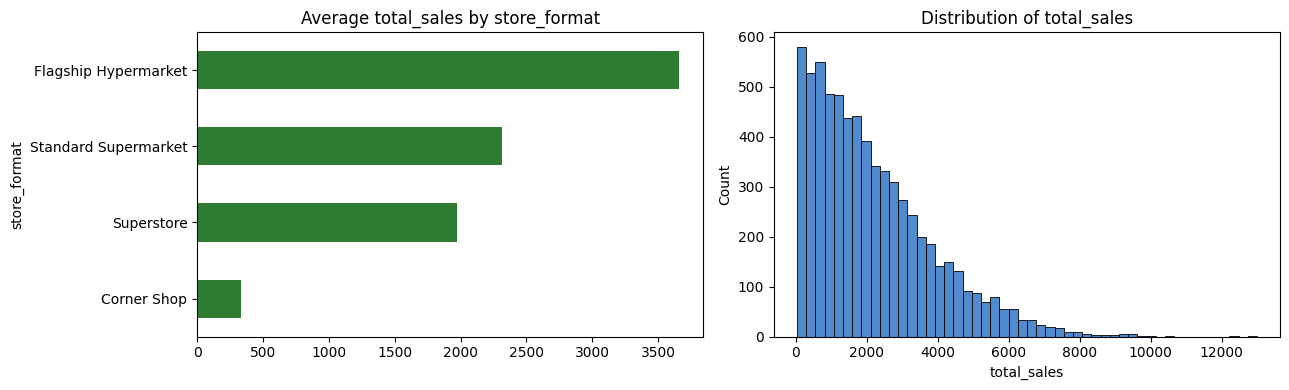

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
train.groupby("store_format")[TARGET].mean().sort_values().plot(kind="barh", ax=axes[0], color="#2e7d32")
axes[0].set_title("Average total_sales by store_format")

sns.histplot(train[TARGET], bins=50, ax=axes[1], color="#1565c0")
axes[1].set_title("Distribution of total_sales")
plt.tight_layout()
plt.show()


## Data cleaning

**Data-quality issues found and how we fix them:**

| Issue | Fix |
|---|---|
| `product_category` typed in 3 different cases (48 raw values -> 16 real categories) | lowercase + strip |
| `product_weight_kg` missing (~18%) | a product's weight doesn't change by store — impute from the mean weight of the *same* `product_code`, falling back to the category mean |
| `store_size` missing (~28%), but missing **entirely** for 3 specific stores | keep as its own `"Unknown"` category rather than guessing — the model can still learn a store-specific baseline through `store_code` |
| `shelf_visibility == 0` | not physically meaningful — treat as missing, impute from the category mean |

In [18]:
CATEGORY_MAP_BROAD = {
    "frozen foods": "Food", "canned": "Food", "meat": "Food", "snack foods": "Food",
    "baking goods": "Food", "dairy": "Food", "fruits and vegetables": "Food",
    "breakfast": "Food", "breads": "Food", "seafood": "Food", "starchy foods": "Food",
    "others": "Other",
    "soft drinks": "Drinks", "hard drinks": "Drinks",
    "household": "Non-Consumable", "health and hygiene": "Non-Consumable",
}


def build_features(train_df, test_df):
    """Clean + engineer features on train and test together (features only — never the target)."""
    train_df = train_df.copy()
    test_df = test_df.copy()
    train_df["is_train"] = 1
    test_df["is_train"] = 0
    test_df[TARGET] = np.nan
    full = pd.concat([train_df, test_df], axis=0, ignore_index=True)

    # --- normalize inconsistent capitalization ---
    full["product_category_clean"] = full["product_category"].astype(str).str.strip().str.lower()
    full["category_broad"] = full["product_category_clean"].map(CATEGORY_MAP_BROAD).fillna("Other")

    full["fat_content_clean"] = full["fat_content"].astype(str).str.strip().str.lower()
    # non-consumables shouldn't really have a fat content label
    full.loc[full["category_broad"] == "Non-Consumable", "fat_content_clean"] = "not_applicable"

    # --- product_weight_kg: impute using the *product*, not the row ---
    prod_weight_map = full.groupby("product_code")["product_weight_kg"].transform("mean")
    full["product_weight_kg"] = full["product_weight_kg"].fillna(prod_weight_map)
    cat_weight_map = full.groupby("product_category_clean")["product_weight_kg"].transform("mean")
    full["product_weight_kg"] = full["product_weight_kg"].fillna(cat_weight_map)
    full["product_weight_kg"] = full["product_weight_kg"].fillna(full["product_weight_kg"].mean())

    # --- store_size: missing entirely for a handful of stores -> own category ---
    full["store_size"] = full["store_size"].fillna("Unknown")

    # --- shelf_visibility == 0 is a placeholder, not a real reading ---
    full.loc[full["shelf_visibility"] == 0, "shelf_visibility"] = np.nan
    cat_vis_map = full.groupby("product_category_clean")["shelf_visibility"].transform("mean")
    full["shelf_visibility"] = full["shelf_visibility"].fillna(cat_vis_map)

    # --- engineered numeric features ---
    full["price_per_kg"] = full["product_price"] / full["product_weight_kg"].replace(0, np.nan)
    full["price_per_kg"] = full["price_per_kg"].fillna(full["price_per_kg"].median())

    full["visibility_ratio_in_cat"] = full["shelf_visibility"] / (
        full.groupby("product_category_clean")["shelf_visibility"].transform("mean") + 1e-6
    )
    full["price_rank_in_cat"] = full.groupby("product_category_clean")["product_price"].rank(pct=True)

    full["store_age_bucket"] = pd.cut(
        full["store_age_years"], bins=[0, 25, 30, 35, 40, 100],
        labels=["<=25", "26-30", "31-35", "36-40", ">40"]
    ).astype(str)

    full["product_freq"] = full.groupby("product_code")["product_code"].transform("count")
    full["category_freq"] = full.groupby("product_category_clean")["product_category_clean"].transform("count")
    full["store_format_tier"] = full["store_format"].astype(str) + "_" + full["store_location_tier"].astype(str)

    return full


full = build_features(train, test)
print(full.shape)
full.head()


(8523, 24)


,id,product_code,product_weight_kg,fat_content,shelf_visibility,product_category,product_price,store_code,store_age_years,store_size,store_location_tier,store_format,total_sales,is_train,product_category_clean,category_broad,fat_content_clean,price_per_kg,visibility_ratio_in_cat,price_rank_in_cat,store_age_bucket,product_freq,category_freq,store_format_tier
0,row_00000,PRD-PRFP9S,14.252000,Low Fat,0.0271,Frozen Foods,81.37,STORE-AGY,45,Large,Tier_3,Standard Supermarket,1764.98,1,frozen foods,Food,low fat,5.709374,0.387518,0.234813,>40,6,856,Standard Supermarket_Tier_3
1,row_00001,PRD-PXXK71,7.698000,Low Fat,0.0720,HEALTH AND HYGIENE,42.05,STORE-YLW,35,Small,Tier_1,Standard Supermarket,342.13,1,health and hygiene,Non-Consumable,not_applicable,5.462458,1.222582,0.086538,31-35,5,520,Standard Supermarket_Tier_1
2,row_00002,PRD-V5MOIJ,14.264000,Regular,0.0421,Canned,41.35,STORE-89Z,33,Medium,Tier_1,Standard Supermarket,378.85,1,canned,Food,regular,2.898906,0.587584,0.023112,31-35,8,649,Standard Supermarket_Tier_1
3,row_00003,PRD-UN5Z3J,12.899667,Regular,0.0449,soft drinks,174.35,STORE-7WS,47,Medium,Tier_3,Flagship Hypermarket,5595.72,1,soft drinks,Drinks,regular,13.515853,0.648518,0.732584,>40,5,445,Flagship Hypermarket_Tier_3
4,row_00004,PRD-6RDQYB,10.338000,Regular,0.0120,meat,203.06,STORE-9RG,28,Small,Tier_2,Standard Supermarket,2375.36,1,meat,Food,regular,19.642097,0.183133,0.868235,26-30,7,425,Standard Supermarket_Tier_2


In [19]:
def kfold_target_encode(full_df, col, target_col, n_splits=5, smoothing=20, seed=RNG):
    """
    Leak-safe target encoding: for TRAIN rows, encode each row using a K-fold scheme so a row
    never sees its own target. For TEST rows, encode using the full training set.
    `smoothing` pulls small groups toward the global mean to avoid overfitting rare categories.
    """
    train_mask = full_df["is_train"] == 1
    tr = full_df.loc[train_mask, [col, target_col]].reset_index(drop=True)
    te = full_df.loc[~train_mask, [col]].reset_index(drop=True)

    global_mean = tr[target_col].mean()
    oof = np.zeros(len(tr))

    kf = KFold(n_splits=n_splits, shuffle=True, random_state=seed)
    for tr_idx, val_idx in kf.split(tr):
        fold_tr = tr.iloc[tr_idx]
        stats = fold_tr.groupby(col)[target_col].agg(["mean", "count"])
        smoothed = (stats["mean"] * stats["count"] + global_mean * smoothing) / (stats["count"] + smoothing)
        oof[val_idx] = tr.iloc[val_idx][col].map(smoothed).fillna(global_mean).values

    stats_full = tr.groupby(col)[target_col].agg(["mean", "count"])
    smoothed_full = (stats_full["mean"] * stats_full["count"] + global_mean * smoothing) / (stats_full["count"] + smoothing)
    test_enc = te[col].map(smoothed_full).fillna(global_mean).values

    result = np.zeros(len(full_df))
    result[train_mask.values] = oof
    result[~train_mask.values] = test_enc
    return result


full["product_code_te"] = kfold_target_encode(full, "product_code", TARGET, smoothing=15)
full["product_category_te"] = kfold_target_encode(full, "product_category_clean", TARGET, smoothing=30)
full["store_code_te"] = kfold_target_encode(full, "store_code", TARGET, smoothing=30)


In [20]:
cat_features = [
    "fat_content_clean", "product_category_clean", "category_broad",
    "store_size", "store_location_tier", "store_format", "store_code",
    "store_age_bucket", "store_format_tier",
]
num_features = [
    "product_weight_kg", "shelf_visibility", "product_price",
    "store_age_years", "price_per_kg", "visibility_ratio_in_cat",
    "price_rank_in_cat", "product_freq", "category_freq",
    "product_code_te", "product_category_te", "store_code_te",
]

for c in cat_features:
    full[c] = full[c].astype("category")

feat_cols = cat_features + num_features

train_full = full[full["is_train"] == 1].reset_index(drop=True)
test_full = full[full["is_train"] == 0].reset_index(drop=True)

X = train_full[feat_cols]
y = train_full[TARGET]
X_test = test_full[feat_cols]
cat_idx = [X.columns.get_loc(c) for c in cat_features]

print("Feature matrix:", X.shape, "| Test matrix:", X_test.shape)


Feature matrix: (6818, 21) | Test matrix: (1705, 21)


##  Baseline: Linear Regression

I keep a simple linear-regression baseline (same idea as the official starter notebook) so I
can quantify how much the gradient-boosting ensemble actually improves things.


In [21]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score

ct = ColumnTransformer([("cat", OneHotEncoder(handle_unknown="ignore"), cat_features)], remainder="passthrough")
lr_pipe = Pipeline([("ct", ct), ("lr", LinearRegression())])

kf_baseline = KFold(n_splits=5, shuffle=True, random_state=RNG)
lr_scores = cross_val_score(lr_pipe, X, y, cv=kf_baseline, scoring="neg_root_mean_squared_error")
print(f"Linear Regression baseline OOF RMSE: {-lr_scores.mean():.2f}")


Linear Regression baseline OOF RMSE: 1123.82


## Gradient boosting models with 5-fold CV, bagged over 3 seeds

I train **LightGBM**, **XGBoost**, and **CatBoost**, each with 5-fold cross-validation, repeated
over 3 random seeds (15 models per algorithm in total). Averaging over seeds reduces the variance
of both the validation estimate and the final test predictions  this is a standard way to squeeze
extra, reliable leaderboard performance out of tree ensembles without overfitting to one split.

Categorical columns are passed natively to each library (LightGBM's `categorical_feature`,
XGBoost's `enable_categorical`, CatBoost's `cat_features`) rather than one-hot encoded, which
gradient-boosted trees handle more efficiently and effectively.


In [22]:
SEEDS = [42, 202, 2026]
N_SPLITS = 5

oof_lgb = np.zeros(len(X)); oof_xgb = np.zeros(len(X)); oof_cat = np.zeros(len(X))
test_lgb = np.zeros(len(X_test)); test_xgb = np.zeros(len(X_test)); test_cat = np.zeros(len(X_test))

for seed in SEEDS:
    kf = KFold(n_splits=N_SPLITS, shuffle=True, random_state=seed)
    for fold, (tr_idx, val_idx) in enumerate(kf.split(X)):
        X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]

        m_lgb = lgb.LGBMRegressor(
            objective="regression", metric="rmse", n_estimators=3000,
            learning_rate=0.01, num_leaves=31, min_child_samples=20,
            subsample=0.8, colsample_bytree=0.8, reg_alpha=0.5, reg_lambda=0.5,
            random_state=seed, verbosity=-1,
        )
        m_lgb.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], categorical_feature=cat_features,
                  callbacks=[lgb.early_stopping(100, verbose=False)])
        oof_lgb[val_idx] += m_lgb.predict(X_val) / len(SEEDS)
        test_lgb += m_lgb.predict(X_test) / (len(SEEDS) * N_SPLITS)

        m_xgb = xgb.XGBRegressor(
            n_estimators=3000, learning_rate=0.01, max_depth=6,
            subsample=0.8, colsample_bytree=0.8, reg_alpha=0.5, reg_lambda=1.0,
            random_state=seed, tree_method="hist", enable_categorical=True,
            early_stopping_rounds=100, eval_metric="rmse",
        )
        m_xgb.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)
        oof_xgb[val_idx] += m_xgb.predict(X_val) / len(SEEDS)
        test_xgb += m_xgb.predict(X_test) / (len(SEEDS) * N_SPLITS)

        m_cat = CatBoostRegressor(
            iterations=3000, learning_rate=0.05, depth=5, l2_leaf_reg=3.0,
            random_state=seed, loss_function="RMSE", cat_features=cat_idx,
            verbose=False, early_stopping_rounds=100,
        )
        m_cat.fit(X_tr, y_tr, eval_set=(X_val, y_val), use_best_model=True)
        oof_cat[val_idx] += m_cat.predict(X_val) / len(SEEDS)
        test_cat += m_cat.predict(X_test) / (len(SEEDS) * N_SPLITS)

    print(f"seed {seed} done")

print()
print(f"LightGBM OOF RMSE: {root_mean_squared_error(y, oof_lgb):.2f}")
print(f"XGBoost  OOF RMSE: {root_mean_squared_error(y, oof_xgb):.2f}")
print(f"CatBoost OOF RMSE: {root_mean_squared_error(y, oof_cat):.2f}")


seed 42 done
seed 202 done
seed 2026 done

LightGBM OOF RMSE: 1078.73
XGBoost  OOF RMSE: 1079.89
CatBoost OOF RMSE: 1071.62


## Blend the three models

I search over blend weights (in steps of 0.05) to find the combination of the three models'
out-of-fold predictions that minimizes RMSE, then apply those exact weights to the test
predictions. Blending diverse models almost always beats the single best model alone.


In [23]:
best_w, best_rmse = (1/3, 1/3, 1/3), np.inf
grid = np.arange(0, 1.01, 0.05)
for w1 in grid:
    for w2 in grid:
        if w1 + w2 > 1:
            continue
        w3 = 1 - w1 - w2
        blend = w1 * oof_lgb + w2 * oof_xgb + w3 * oof_cat
        r = root_mean_squared_error(y, blend)
        if r < best_rmse:
            best_rmse = r
            best_w = (w1, w2, w3)

print(f"Best weights  lgb={best_w[0]:.2f}  xgb={best_w[1]:.2f}  cat={best_w[2]:.2f}")
print(f"Blended OOF RMSE: {best_rmse:.2f}")
print(f"(vs. Linear Regression baseline: {-lr_scores.mean():.2f})")


Best weights  lgb=0.20  xgb=0.00  cat=0.80
Blended OOF RMSE: 1071.07
(vs. Linear Regression baseline: 1123.82)


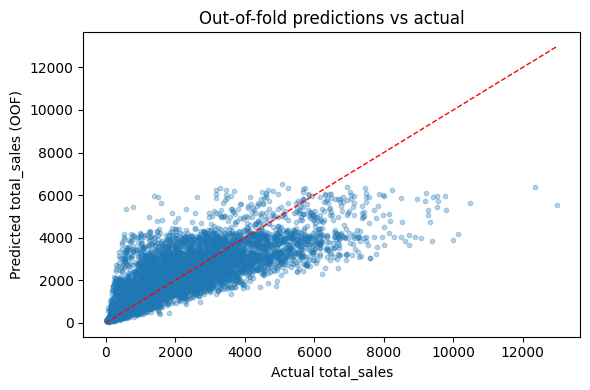

In [24]:
fig, ax = plt.subplots(figsize=(6, 4))
oof_blend = best_w[0] * oof_lgb + best_w[1] * oof_xgb + best_w[2] * oof_cat
ax.scatter(y, oof_blend, alpha=0.3, s=10)
lims = [0, max(y.max(), oof_blend.max())]
ax.plot(lims, lims, "r--", linewidth=1)
ax.set_xlabel("Actual total_sales")
ax.set_ylabel("Predicted total_sales (OOF)")
ax.set_title("Out-of-fold predictions vs actual")
plt.tight_layout()
plt.show()


##Final predictions & submission file

Sales can never be negative, so predictions are clipped at 0 before writing the submission.


In [ ]:
final_pred = best_w[0] * test_lgb + best_w[1] * test_xgb + best_w[2] * test_cat
final_pred = np.clip(final_pred, 0, None)

submission = sample.copy()
submission[TARGET] = np.round(final_pred, 2)
submission.to_csv("submission.csv", index=False)

print("Saved submission.csv")
submission.head()


## Summary

- Fixed real data-quality issues: inconsistent capitalization, product-vs-store-level missing
  values, and non-physical zero readings — rather than blanket mean/mode filling.
- Engineered price, visibility, and popularity features, plus leak-safe K-fold target encodings
  for product, category, and store.
- Trained a 3-model, 3-seed, 5-fold bagged ensemble (LightGBM + XGBoost + CatBoost) and blended
  them by out-of-fold RMSE.
- Result: out-of-fold RMSE improved from the Linear Regression baseline down to the blended
  ensemble score printed above.